In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('\\ML\\Logistic_Reqression\\placement.csv')

In [6]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
df.shape

(100, 4)

In [9]:
df = df.iloc[:,1:]

In [10]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


 Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [11]:
import matplotlib.pyplot as plt

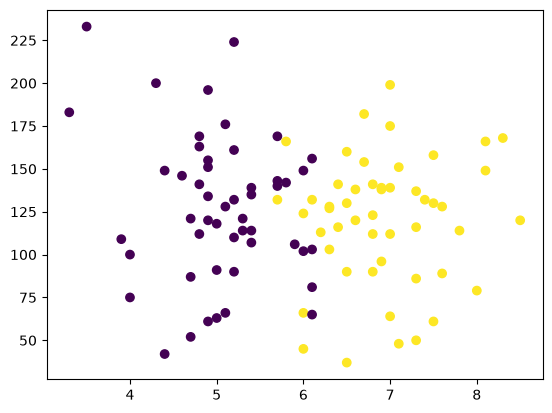

In [13]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [14]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [15]:
y.shape

(100,)

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)
     

In [17]:
X_train

,cgpa,iq
81,5.4,107.0
27,6.0,124.0
15,5.1,176.0
88,4.4,149.0
16,5.2,224.0
...,...,...
14,6.1,103.0
46,5.3,114.0
45,6.0,66.0
56,6.1,65.0


In [18]:
y_train

81    0
27    1
15    0
88    0
16    0
     ..
14    0
46    0
45    1
56    0
60    1
Name: placement, Length: 90, dtype: int64

In [19]:
X_test

,cgpa,iq
51,4.8,141.0
2,5.3,121.0
37,8.1,149.0
62,6.0,102.0
86,5.1,128.0
29,7.0,112.0
53,8.3,168.0
97,6.7,182.0
44,7.5,61.0
90,7.3,86.0


In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
X_train = scaler.fit_transform(X_train)

In [23]:
X_train

array([[-0.47007522, -0.40820108],
       [ 0.0700112 ,  0.01436161],
       [-0.74011843,  1.3069063 ],
       [-1.37021925,  0.63577732],
       [-0.65010402,  2.50002447],
       [-0.74011843, -1.42732285],
       [ 1.24019845,  0.33749778],
       [ 2.32037129, -0.08506491],
       [ 0.97015524,  0.38721104],
       [ 0.97015524,  1.28204967],
       [-0.83013283, -0.13477816],
       [-0.1100176 ,  0.46178092],
       [-0.0200032 , -0.43305771],
       [ 1.42022725,  0.85948698],
       [-1.10017604, -1.77531565],
       [-0.92014724,  0.68549058],
       [ 1.51024166, -0.85562039],
       [ 0.88014083,  0.36235441],
       [ 1.24019845, -0.18449142],
       [ 0.61009762,  0.36235441],
       [ 0.16002561,  0.80977372],
       [ 0.79012643, -0.28391794],
       [-0.1100176 ,  1.05834001],
       [-0.65010402,  0.93405687],
       [ 0.88014083, -0.68162399],
       [ 1.69027046, -0.23420468],
       [-0.20003201,  0.48663755],
       [ 0.52008322, -0.83076377],
       [-0.92014724,

In [24]:
X_test = scaler.transform(X_test)

In [25]:
X_test

array([[-1.01016164,  0.43692429],
       [-0.56008962, -0.06020828],
       [ 1.96031368,  0.63577732],
       [ 0.0700112 , -0.53248422],
       [-0.74011843,  0.11378812],
       [ 0.97015524, -0.28391794],
       [ 2.14034248,  1.10805327],
       [ 0.70011203,  1.45604607],
       [ 1.42022725, -1.551606  ],
       [ 1.24019845, -0.93019028]])

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
clf = LogisticRegression()

In [28]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [29]:
y_pred = clf.predict(X_test)

In [30]:
y_test

51    0
2     0
37    1
62    0
86    0
29    1
53    1
97    1
44    1
90    1
Name: placement, dtype: int64

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_test,y_pred)

0.9

In [33]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

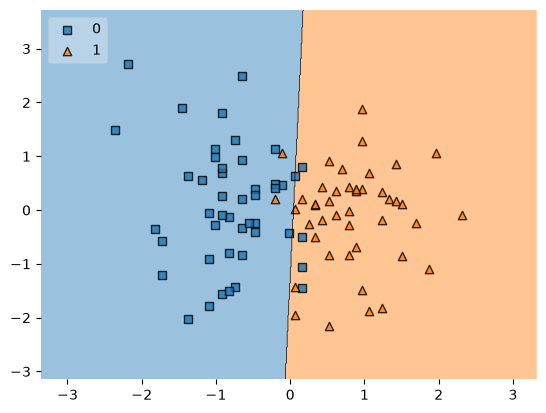

In [34]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [35]:
import pickle

In [36]:
pickle.dump(clf,open('model.pkl','wb'))